#### Free up GPU memory

In [13]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [14]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 272.71 MB | Reserved: 6756.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 272.71 MB | Reserved: 320.00 MB


## Approach 2: Two-stage Pipeline

### Stage 1: RF-DETR Detection (unchanged)
Keep your existing trained RF-DETR model (the baseline checkpoint_best_total.pth) for bounding box detection only. At inference, run it to get bounding boxes with confidence > some threshold, but ignore its class predictions.

### Stage 2: Hyperbolic Crop Classifier

#### Step 1 -- Build a crop dataset:

In [2]:
import os
import json
from PIL import Image
from tqdm import tqdm
from collections import Counter

def build_crop_dataset(coco_json_path, images_dir, output_dir, min_size=15):
    """Extract vehicle crops from COCO annotations into ImageFolder structure."""
    with open(coco_json_path) as f:
        ann = json.load(f)

    class_names = {c["id"]: c["name"] for c in ann["categories"]}

    for cls_name in class_names.values():
        os.makedirs(os.path.join(output_dir, cls_name), exist_ok=True)

    img_lookup = {img["id"]: img for img in ann["images"]}
    counts = Counter()
    skipped = 0

    for i, a in enumerate(tqdm(ann["annotations"], desc="Cropping")):
        x, y, w, h = a["bbox"]
        if w < min_size or h < min_size:
            skipped += 1
            continue

        img_info = img_lookup[a["image_id"]]
        img_path = os.path.join(images_dir, img_info["file_name"])
        img = Image.open(img_path).convert("RGB")

        crop = img.crop((x, y, x + w, y + h))
        cls_name = class_names[a["category_id"]]
        crop.save(os.path.join(output_dir, cls_name, f"crop_{i:06d}.jpg"))
        counts[cls_name] += 1

    print(f"\nCrop extraction complete. Skipped {skipped} tiny boxes.")
    for name, count in sorted(counts.items()):
        print(f"  {name:15s}: {count}")
    return class_names

In [3]:
DATASET_DIR = dataset.location  # from Roboflow download earlier

for split in ["train", "valid", "test"]:
    json_path = os.path.join(DATASET_DIR, split, "_annotations.coco.json")
    images_dir = os.path.join(DATASET_DIR, split)
    output_dir = os.path.join("crops", split)

    if os.path.exists(json_path):
        print(f"\n{'='*50}")
        print(f"Processing {split} split...")
        build_crop_dataset(json_path, images_dir, output_dir)
    else:
        print(f"Skipping {split} (no annotation file found)")


Processing train split...


Cropping: 100%|██████████| 31355/31355 [01:09<00:00, 448.60it/s]



Crop extraction complete. Skipped 136 tiny boxes.
  Bus            : 114
  Motorcycle     : 343
  Pickup         : 11028
  Sedan          : 10794
  Suv            : 2151
  Truck          : 5242
  Van            : 1547

Processing valid split...


Cropping: 100%|██████████| 8572/8572 [00:19<00:00, 446.95it/s]



Crop extraction complete. Skipped 39 tiny boxes.
  Bus            : 37
  Motorcycle     : 77
  Pickup         : 2981
  Sedan          : 2987
  Suv            : 606
  Truck          : 1457
  Van            : 388

Processing test split...


Cropping: 100%|██████████| 1660/1660 [00:03<00:00, 473.46it/s]


Crop extraction complete. Skipped 11 tiny boxes.
  Bus            : 12
  Motorcycle     : 51
  Pickup         : 568
  Sedan          : 605
  Suv            : 116
  Truck          : 221
  Van            : 76


#### Step 2 -- Build a lightweight hyperbolic classifier:
This is where the actual hyperbolic approach lives. Rather than a ProtoNet (which is a few-shot method you don't actually need since you have thousands of annotations), use a simple CNN backbone + HyperbolicMLR:

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
from hypll.manifolds.poincare_ball import Curvature, PoincareBall
from hypll.manifolds.poincare_ball.math.diffgeom import expmap0
from hypll.manifolds.poincare_ball.math.linalg import poincare_hyperplane_dists


class HyperbolicVehicleClassifier(nn.Module):
    """
    MobileNetV3-Small backbone -> projection -> Poincare ball -> hyperplane classifier.

    Uses the same HNN++ classification approach as your Approach 1 head:
    expmap0 to map features onto the ball, then signed geodesic distances
    to learnable hyperbolic hyperplanes.
    """
    def __init__(self, num_classes=7, embed_dim=128, curvature=1.0):
        super().__init__()

        backbone = models.mobilenet_v3_small(weights="DEFAULT")
        backbone.classifier = nn.Identity()
        self.backbone = backbone  # outputs 576-d

        self.manifold = PoincareBall(c=Curvature(value=curvature, requires_grad=False))

        self.proj = nn.Sequential(
            nn.Linear(576, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

        # HNN++ hyperplane parameters (same formulation as your Approach 1)
        self.z = nn.Parameter(torch.empty(embed_dim, num_classes))
        nn.init.normal_(self.z, mean=0, std=(2 * embed_dim * num_classes) ** -0.5)
        self.r = nn.Parameter(torch.zeros(num_classes))
        self.bias = nn.Parameter(torch.zeros(num_classes))

    def forward(self, x):
        features = self.backbone(x)          # [B, 576]
        embeddings = self.proj(features)     # [B, embed_dim]

        c = self.manifold.c()
        x_ball = expmap0(embeddings, c, dim=-1)

        logits = poincare_hyperplane_dists(
            x_ball, self.z, self.r, c, dim=-1
        )
        logits = logits + self.bias

        return logits


class EuclideanVehicleClassifier(nn.Module):
    """
    Euclidean baseline for comparison -- same architecture minus
    the hyperbolic mapping. Replace the Poincare ball with a plain linear head.
    """
    def __init__(self, num_classes=7, embed_dim=128):
        super().__init__()
        backbone = models.mobilenet_v3_small(weights="DEFAULT")
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        self.head = nn.Sequential(
            nn.Linear(576, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

#### Step 3 -- Train the classifier:

In [6]:
import time
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Transforms ---
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# --- Datasets ---
train_dataset = datasets.ImageFolder("crops/train", transform=transform_train)
val_dataset = datasets.ImageFolder("crops/valid", transform=transform_val)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

# --- Class-balanced sampler (critical given Bus=115 vs Sedan=10840) ---
targets = torch.tensor(train_dataset.targets)
class_counts = torch.bincount(targets)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_dataset, batch_size=64, sampler=sampler, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
for i, name in enumerate(class_names):
    print(f"  {name:15s}: {class_counts[i].item()} train crops")

Using device: cuda
Classes (7): ['Bus', 'Motorcycle', 'Pickup', 'Sedan', 'Suv', 'Truck', 'Van']
Train samples: 31219, Val samples: 8533
  Bus            : 114 train crops
  Motorcycle     : 343 train crops
  Pickup         : 11028 train crops
  Sedan          : 10794 train crops
  Suv            : 2151 train crops
  Truck          : 5242 train crops
  Van            : 1547 train crops


In [ ]:
NUM_EPOCHS = 40
USE_HYPERBOLIC = True  # Set to False to train Euclidean baseline for comparison

if USE_HYPERBOLIC:
    classifier = HyperbolicVehicleClassifier(
        num_classes=num_classes, embed_dim=128, curvature=1.0
    ).to(device)
    print("Training HYPERBOLIC classifier")
else:
    classifier = EuclideanVehicleClassifier(
        num_classes=num_classes, embed_dim=128
    ).to(device)
    print("Training EUCLIDEAN classifier")

optimizer = torch.optim.AdamW(classifier.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_per_class": []}

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    classifier.train()
    running_loss = 0.0
    t0 = time.time()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = classifier(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)

    # --- Validate ---
    classifier.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    per_class_correct = torch.zeros(num_classes)
    per_class_total = torch.zeros(num_classes)

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = classifier(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()

            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            for c in range(num_classes):
                mask = labels == c
                per_class_correct[c] += (preds[mask] == labels[mask]).sum().item()
                per_class_total[c] += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    per_class_acc = per_class_correct / per_class_total.clamp(min=1)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_per_class"].append(per_class_acc.tolist())

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
        f"train_loss: {avg_train_loss:.4f} | "
        f"val_loss: {avg_val_loss:.4f} | "
        f"val_acc: {val_acc:.4f} | "
        f"lr: {scheduler.get_last_lr()[0]:.6f} | "
        f"{elapsed:.1f}s"
    )

    # Per-class breakdown every 5 epochs
    if (epoch + 1) % 5 == 0 or val_acc > best_val_acc:
        for i, name in enumerate(class_names):
            print(f"    {name:15s}: {per_class_acc[i]:.4f}")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        tag = "hyperbolic" if USE_HYPERBOLIC else "euclidean"
        save_path = f"output/{tag}_classifier_best.pth"
        torch.save(classifier.state_dict(), save_path)
        print(f"    ** New best ({val_acc:.4f}), saved to {save_path}")

print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.4f}")

#### Step 4 -- Inference pipeline:

In [19]:
import numpy as np
from PIL import Image
from rfdetr import RFDETRBase

class TwoStagePipeline:
    """
    Stage 1: RF-DETR detects bounding boxes (class-agnostic).
    Stage 2: Hyperbolic classifier re-labels each crop.
    """
    def __init__(self, detector, classifier, class_names, device, conf_threshold=0.3):
        self.detector = detector
        self.classifier = classifier
        self.class_names = class_names
        self.device = device
        self.conf_threshold = conf_threshold
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def predict(self, image, return_sv=False, override_below=0.7):
        """
        Only reclassify detections where RF-DETR's class confidence
        is below override_below. High-confidence detections are kept as-is.
        """
        detections = self.detector.predict(image, threshold=self.conf_threshold)

        if len(detections) == 0:
            if return_sv:
                return detections
            return []

        if isinstance(image, str):
            pil_img = Image.open(image).convert("RGB")
        elif isinstance(image, np.ndarray):
            pil_img = Image.fromarray(image)
        elif isinstance(image, Image.Image):
            pil_img = image
        else:
            raise TypeError(f"Unsupported image type: {type(image)}")

        new_class_ids = detections.class_id.copy()

        # Only reclassify low-confidence detections
        low_conf_mask = detections.confidence < override_below
        low_conf_indices = np.where(low_conf_mask)[0]

        if len(low_conf_indices) > 0:
            crops = []
            valid_indices = []
            for idx in low_conf_indices:
                x1, y1, x2, y2 = map(int, detections.xyxy[idx])
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = max(x1 + 1, x2), max(y1 + 1, y2)
                crop = pil_img.crop((x1, y1, x2, y2))
                if crop.size[0] >= 5 and crop.size[1] >= 5:
                    crops.append(self.transform(crop))
                    valid_indices.append(idx)

            if crops:
                batch = torch.stack(crops).to(self.device)
                with torch.no_grad():
                    logits = self.classifier(batch)
                    preds = logits.argmax(dim=-1).cpu().numpy()

                for idx, pred in zip(valid_indices, preds):
                    new_class_ids[idx] = pred + 1

        if return_sv:
            import supervision as sv
            return sv.Detections(
                xyxy=detections.xyxy,
                confidence=detections.confidence,
                class_id=new_class_ids,
            )

        results = []
        for i in range(len(detections.xyxy)):
            results.append({
                "bbox": detections.xyxy[i],
                "class": self.class_names[new_class_ids[i] - 1]
                        if new_class_ids[i] > 0 else "unknown",
                "confidence": float(detections.confidence[i]),
            })
        return results

#### Step 5 -- Evaluate with COCO mAP (Fair Comparison)

In [20]:
import supervision as sv
from supervision.metrics import MeanAveragePrecision
from tqdm import tqdm

USE_HYPERBOLIC = True
# 1. Load the detector (your baseline RF-DETR with standard head)
print("Loading RF-DETR detector...")
detector = RFDETRBase(pretrain_weights="output/checkpoint_best_total.pth")
detector.optimize_for_inference()

# 2. Load the best hyperbolic classifier
print("Loading hyperbolic classifier...")
tag = "hyperbolic" if USE_HYPERBOLIC else "euclidean"
best_classifier = HyperbolicVehicleClassifier(num_classes=num_classes).to(device)
best_classifier.load_state_dict(
    torch.load(f"output/{tag}_classifier_best.pth", map_location=device)
)
best_classifier.eval()

# 3. Build pipeline
pipeline = TwoStagePipeline(
    detector=detector,
    classifier=best_classifier,
    class_names=class_names,
    device=device,
    conf_threshold=0.0,  # threshold=0 for mAP evaluation (same as your Approach 1 eval)
)

# 4. Load test set ground truth
test_ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

# 5. Run evaluation
targets = []
predictions_baseline = []
predictions_twostage = []

print("Running evaluation on test set...")
for path, image, annotations in tqdm(test_ds):
    pil_image = Image.open(path).convert("RGB")

    # Baseline: RF-DETR only
    det_baseline = detector.predict(pil_image, threshold=0)
    predictions_baseline.append(det_baseline)

    # Two-stage: RF-DETR + hyperbolic classifier
    det_twostage = pipeline.predict(pil_image, return_sv=True)
    predictions_twostage.append(det_twostage)

    targets.append(annotations)

# 6. Compute mAP
print("\n" + "=" * 60)
print("BASELINE (RF-DETR only):")
map_baseline = MeanAveragePrecision()
result_baseline = map_baseline.update(predictions_baseline, targets).compute()
print(result_baseline)

print("\n" + "=" * 60)
print(f"TWO-STAGE (RF-DETR + {tag} classifier):")
map_twostage = MeanAveragePrecision()
result_twostage = map_twostage.update(predictions_twostage, targets).compute()
print(result_twostage)

Loading RF-DETR detector...
[2026-02-26 00:22:30] [INFO] rf-detr - Loading pretrain weights


[2026-02-26 00:22:30] [WARNING] rf-detr - Reinitializing detection head with 7 classes based on pretrained weights, configured for 90.


Loading hyperbolic classifier...
Running evaluation on test set...


100%|██████████| 290/290 [01:31<00:00,  3.18it/s]



BASELINE (RF-DETR only):
Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.822
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.628
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.245
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.556
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.647

TWO-STAGE (RF-DETR + hyperbolic classifier):
Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.480
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.761
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.570
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.234
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.530
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] 

In [21]:
# Sweep override_below threshold to find the sweet spot
from supervision.metrics import MeanAveragePrecision
from tqdm import tqdm

# Reload test dataset (targets already loaded from previous cell)
test_ds_sweep = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print("Threshold sweep: only reclassify detections below each confidence level")
print("=" * 70)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    preds = []
    tgts = []

    for path, image, annotations in test_ds_sweep:
        pil_image = Image.open(path).convert("RGB")
        det = pipeline.predict(pil_image, return_sv=True, override_below=threshold)
        preds.append(det)
        tgts.append(annotations)

    m = MeanAveragePrecision()
    result = m.update(preds, tgts).compute()

    # threshold=1.0 means reclassify everything (same as before)
    # threshold=0.3 means only reclassify very low confidence detections
    label = "(= baseline, no reclassification)" if threshold == 0.0 else ""
    label = "(= full reclassification)" if threshold == 1.0 else label
    print(f"  override_below={threshold:.1f}  →  mAP@50={result.map50:.4f}  mAP@50:95={result.map50_95:.4f}  {label}")

print("=" * 70)
print("(baseline reference: mAP@50=0.822, mAP@50:95=0.525)")

Threshold sweep: only reclassify detections below each confidence level
  override_below=0.3  →  mAP@50=0.8056  mAP@50:95=0.5125  
  override_below=0.4  →  mAP@50=0.7852  mAP@50:95=0.4971  
  override_below=0.5  →  mAP@50=0.7672  mAP@50:95=0.4838  
  override_below=0.6  →  mAP@50=0.7652  mAP@50:95=0.4822  
  override_below=0.7  →  mAP@50=0.7606  mAP@50:95=0.4796  
  override_below=0.8  →  mAP@50=0.7552  mAP@50:95=0.4759  
  override_below=0.9  →  mAP@50=0.7539  mAP@50:95=0.4749  
  override_below=1.0  →  mAP@50=0.7539  mAP@50:95=0.4749  (= full reclassification)
(baseline reference: mAP@50=0.822, mAP@50:95=0.525)


#### Visual Comparison on Sample Images

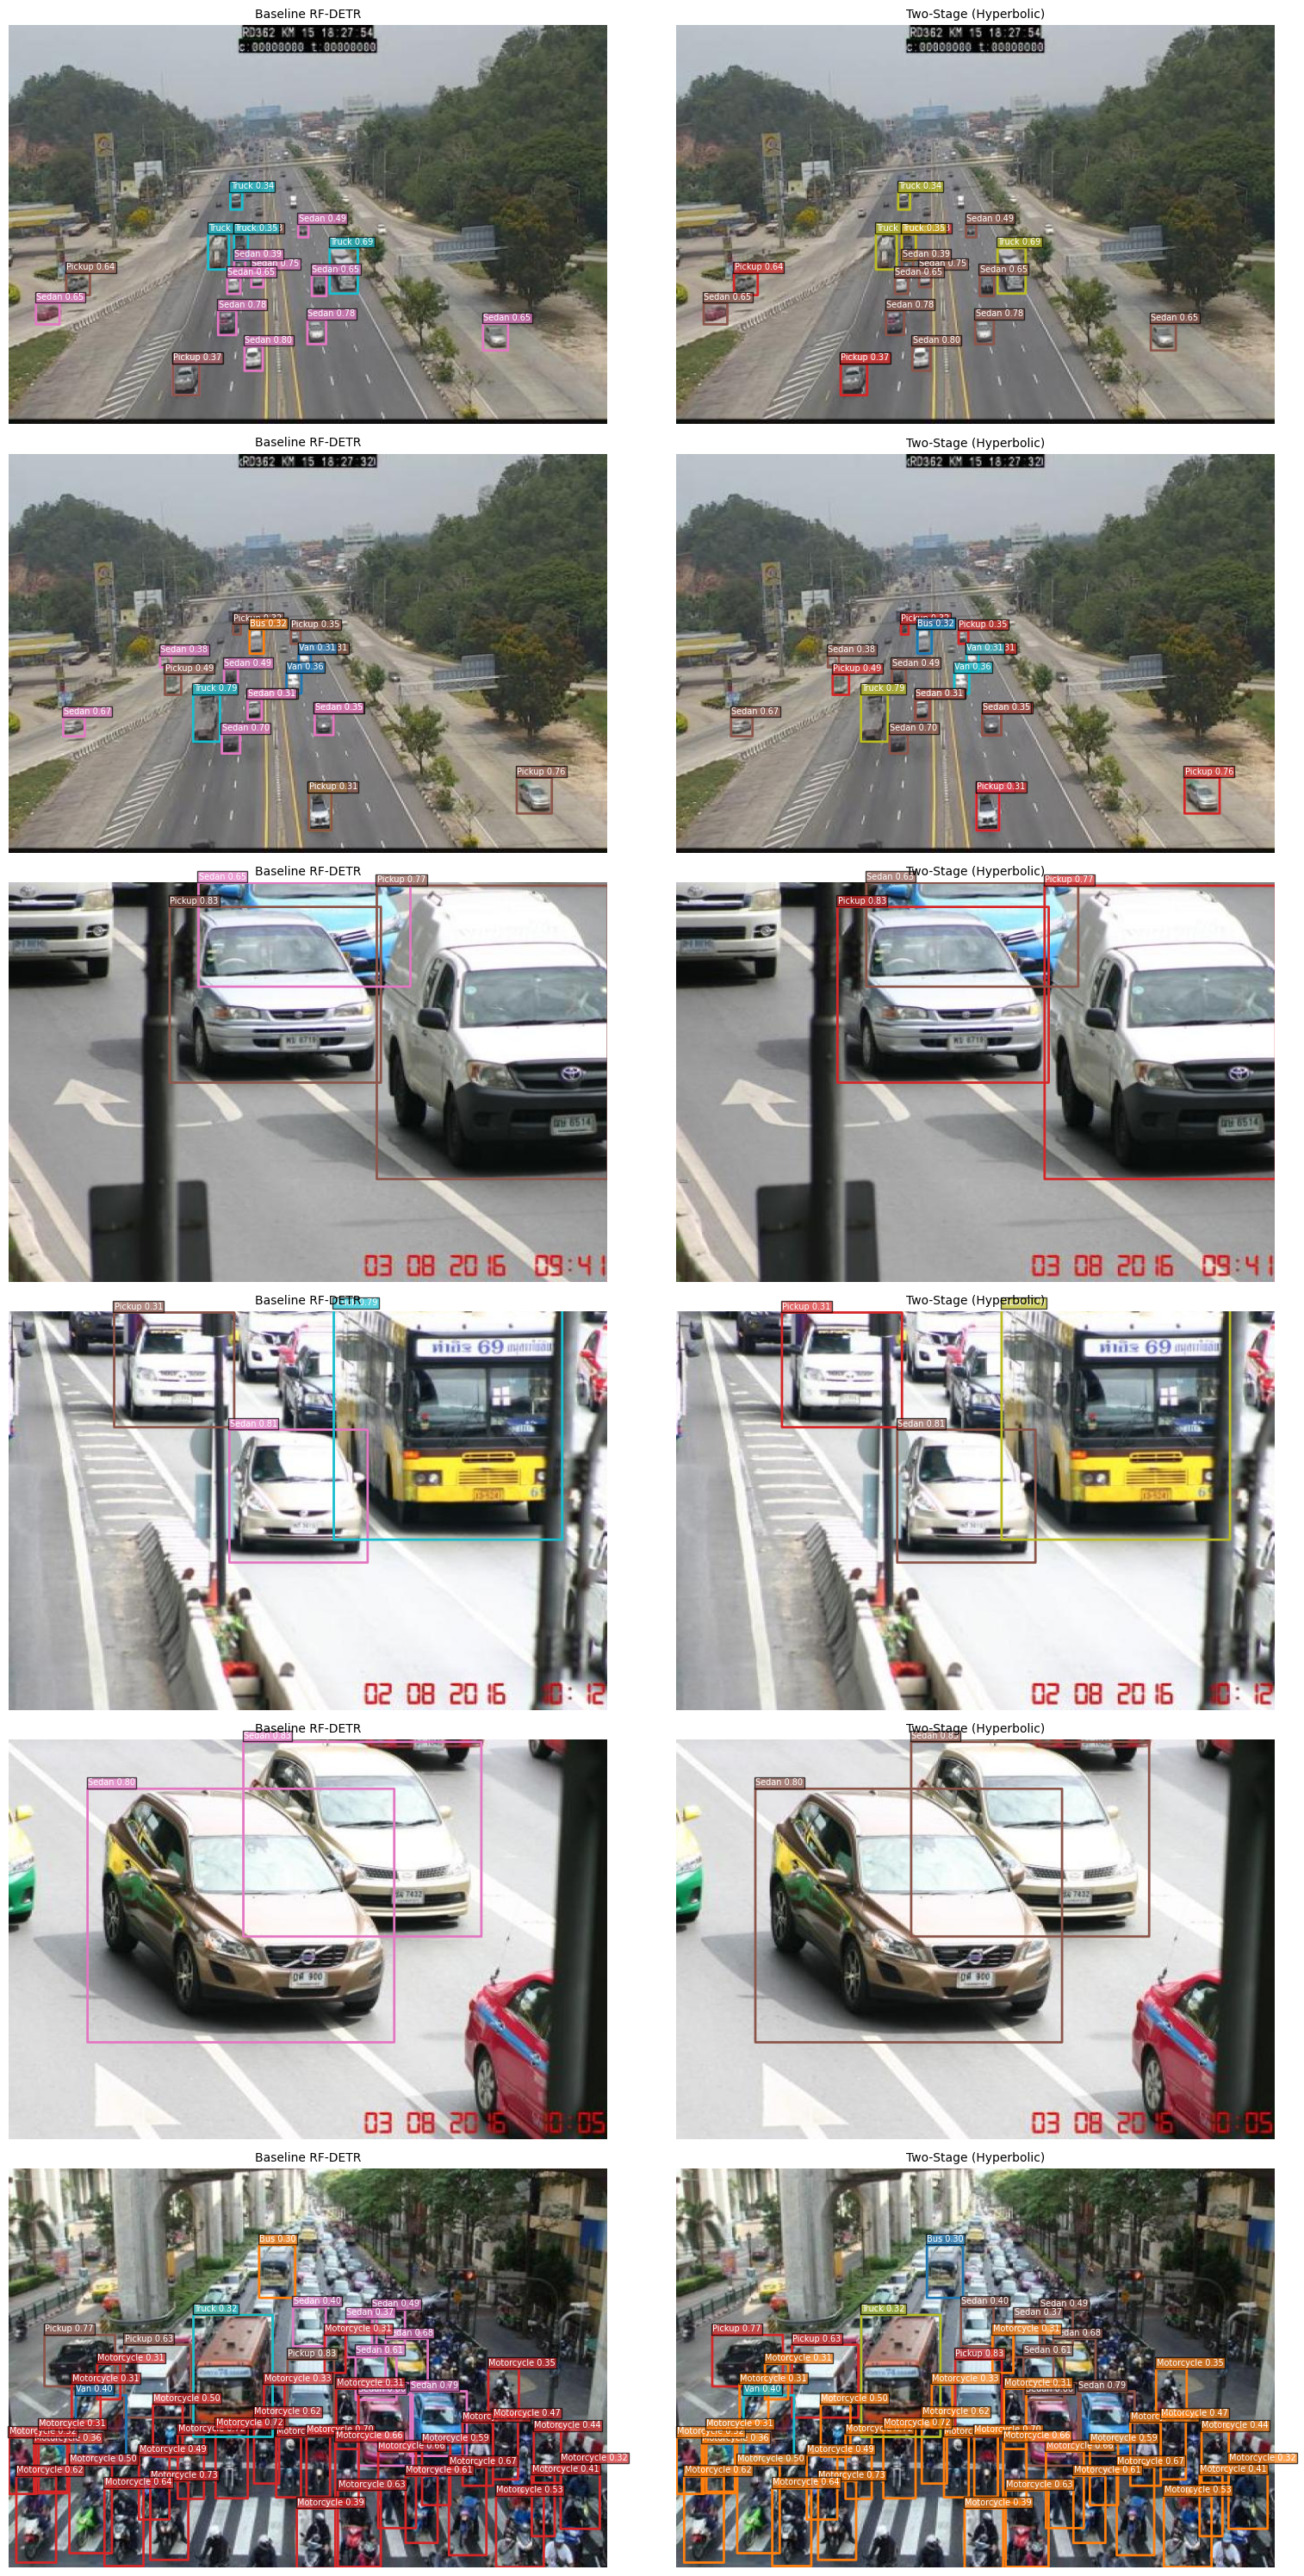

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob

test_images = sorted(glob.glob(f"{dataset.location}/test/*.jpg"))[:6]

fig, axes = plt.subplots(len(test_images), 2, figsize=(16, 5 * len(test_images)))
if len(test_images) == 1:
    axes = axes[np.newaxis, :]

colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
pipeline.conf_threshold = 0.3
for row, img_path in enumerate(test_images):
    pil_img = Image.open(img_path).convert("RGB")
    img_np = np.array(pil_img)

    # Baseline
    det_base = detector.predict(pil_img, threshold=0.3)
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title("Baseline RF-DETR", fontsize=10)
    axes[row, 0].axis("off")
    for i in range(len(det_base.xyxy)):
        x1, y1, x2, y2 = det_base.xyxy[i]
        cid = det_base.class_id[i]
        label = f"{class_names[cid - 1]} {det_base.confidence[i]:.2f}" if cid > 0 else "?"
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=colors[cid % num_classes], facecolor="none"
        )
        axes[row, 0].add_patch(rect)
        axes[row, 0].text(x1, y1 - 4, label, fontsize=7, color="white",
                          bbox=dict(facecolor=colors[cid % num_classes], alpha=0.7, pad=1))

    # Two-stage
    results = pipeline.predict(pil_img, override_below=0.3)
    axes[row, 1].imshow(img_np)
    axes[row, 1].set_title("Two-Stage (Hyperbolic)", fontsize=10)
    axes[row, 1].axis("off")
    for res in results:
        x1, y1, x2, y2 = res["bbox"]
        label = f"{res['class']} {res['confidence']:.2f}"
        cid = class_names.index(res["class"]) if res["class"] in class_names else 0
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=colors[cid], facecolor="none"
        )
        axes[row, 1].add_patch(rect)
        axes[row, 1].text(x1, y1 - 4, label, fontsize=7, color="white",
                          bbox=dict(facecolor=colors[cid], alpha=0.7, pad=1))

plt.tight_layout()
plt.savefig("output/two_stage_comparison.png", dpi=150)
plt.show()

In [13]:
import json

with open(f"{dataset.location}/train/_annotations.coco.json") as f:
    ann = json.load(f)

print("COCO category ordering (what RF-DETR uses):")
for c in ann["categories"]:
    print(f"  id={c['id']}: {c['name']}")

print("\nImageFolder ordering (what the classifier uses):")
for i, name in enumerate(train_dataset.classes):
    print(f"  idx={i}: {name}")

print("\nRF-DETR class_names property:")
print(detector.class_names)

COCO category ordering (what RF-DETR uses):
  id=0: cars-counter
  id=1: Bus
  id=2: Motorcycle
  id=3: Pickup
  id=4: Sedan
  id=5: Suv
  id=6: Truck
  id=7: Van

ImageFolder ordering (what the classifier uses):
  idx=0: Bus
  idx=1: Motorcycle
  idx=2: Pickup
  idx=3: Sedan
  idx=4: Suv
  idx=5: Truck
  idx=6: Van

RF-DETR class_names property:
{1: 'Bus', 2: 'Motorcycle', 3: 'Pickup', 4: 'Sedan', 5: 'Suv', 6: 'Truck', 7: 'Van'}


In [17]:
# Compare how many detections get HELPED vs HURT by reclassification
helped = 0
hurt = 0
unchanged = 0


def box_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

for i, (path, image, gt) in enumerate(tqdm(test_ds)):
    pil_image = Image.open(path).convert("RGB")
    det_baseline = detector.predict(pil_image, threshold=0.3)
    det_twostage = pipeline.predict(pil_image, return_sv=True)

    for j in range(len(det_baseline.xyxy)):
        old_cls = det_baseline.class_id[j]
        new_cls = det_twostage.class_id[j]
        if old_cls == new_cls:
            unchanged += 1
        else:
            # Check which one matches closest ground truth box
            box = det_baseline.xyxy[j]
            best_iou = 0
            gt_cls = None
            for k in range(len(gt.xyxy)):
                iou = box_iou(box, gt.xyxy[k])
                if iou > best_iou:
                    best_iou = iou
                    gt_cls = gt.class_id[k]
            if gt_cls is not None and best_iou > 0.5:
                if new_cls == gt_cls and old_cls != gt_cls:
                    helped += 1
                elif old_cls == gt_cls and new_cls != gt_cls:
                    hurt += 1
                else:
                    unchanged += 1  # both wrong, or no match
            else:
                unchanged += 1

print(f"Unchanged: {unchanged}")
print(f"Helped (wrong→right): {helped}")
print(f"Hurt (right→wrong): {hurt}")
print(f"Net effect: {helped - hurt:+d} detections")


100%|██████████| 290/290 [01:31<00:00,  3.18it/s]

Unchanged: 1486
Helped (wrong→right): 92
Hurt (right→wrong): 61
Net effect: +31 detections
